# Unemployment Analysis with Python

## OASIS INFOBYTE Data Science Internship – Task 2

### Objective
To analyze unemployment trends in India using Python through data cleaning, exploratory data analysis (EDA), and data visualization, with special focus on the impact of COVID-19.

In [1]:
# Import required libraries for data analysis and visualization

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside the notebook
%matplotlib inline

In [2]:
#load the unemployment dataset
df=pd.read_csv("Unemployment in India.csv")

In [3]:
# display the first five rows of the dataset
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [4]:
# check the number of rows and columns
df.shape

(768, 7)

In [5]:
# display dataset information including data types and missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    str    
 1    Date                                     740 non-null    str    
 2    Frequency                                740 non-null    str    
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    str    
dtypes: float64(3), str(4)
memory usage: 42.1 KB


In [6]:
# remove extra spaces from column names
df.columns=df.columns.str.strip()

In [7]:
df.columns

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='str')

In [8]:
# generate summary statistics of numerical columns
df.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


In [9]:
# check for missing values in each column
df.isnull().sum()

Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64

In [10]:
# remove rows containing missing values
df=df.dropna()

In [11]:
# verify dataset size after removing missing values
df.shape

(740, 7)

In [12]:
# Convert the Date column to datetime format

df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)


In [13]:
df.info()

<class 'pandas.DataFrame'>
Index: 740 entries, 0 to 753
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Region                                   740 non-null    str           
 1   Date                                     740 non-null    datetime64[us]
 2   Frequency                                740 non-null    str           
 3   Estimated Unemployment Rate (%)          740 non-null    float64       
 4   Estimated Employed                       740 non-null    float64       
 5   Estimated Labour Participation Rate (%)  740 non-null    float64       
 6   Area                                     740 non-null    str           
dtypes: datetime64[us](1), float64(3), str(3)
memory usage: 46.2 KB


In [14]:
# Calculate average unemployment rate for each region

region_unemployment = df.groupby("Region")["Estimated Unemployment Rate (%)"].mean()

region_unemployment

Region
Andhra Pradesh       7.477143
Assam                6.428077
Bihar               18.918214
Chandigarh          15.991667
Chhattisgarh         9.240357
Delhi               16.495357
Goa                  9.274167
Gujarat              6.663929
Haryana             26.283214
Himachal Pradesh    18.540357
Jammu & Kashmir     16.188571
Jharkhand           20.585000
Karnataka            6.676071
Kerala              10.123929
Madhya Pradesh       7.406429
Maharashtra          7.557500
Meghalaya            4.798889
Odisha               5.657857
Puducherry          10.215000
Punjab              12.031071
Rajasthan           14.058214
Sikkim               7.249412
Tamil Nadu           9.284286
Telangana            7.737857
Tripura             28.350357
Uttar Pradesh       12.551429
Uttarakhand          6.582963
West Bengal          8.124643
Name: Estimated Unemployment Rate (%), dtype: float64

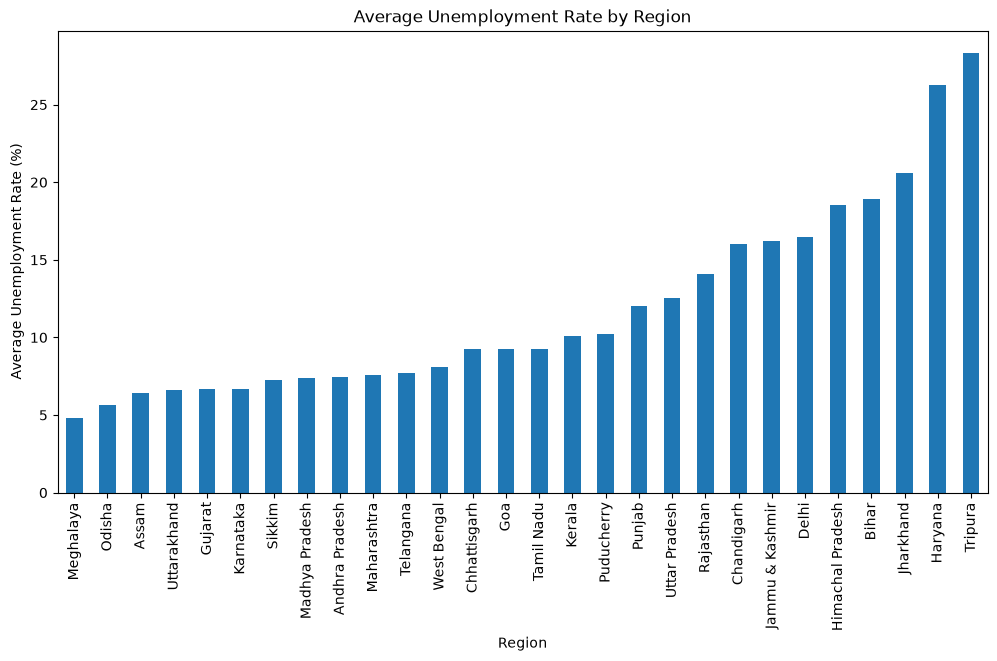

In [15]:
# Plot average unemployment rate by region

plt.figure(figsize=(12,6))

region_unemployment.sort_values().plot(kind="bar")

plt.title("Average Unemployment Rate by Region")
plt.xlabel("Region")
plt.ylabel("Average Unemployment Rate (%)")

plt.show()

The bar chart shows the average unemployment rate across different regions of India. Some regions have noticeably higher unemployment rates than others, indicating differences in employment opportunities and economic conditions.

In [16]:
# extract month names from the Date column
df["Month"]=df["Date"].dt.month_name()

In [17]:
# calculate average unemployment rate for each month
monthly_unemployment=df.groupby("Month")["Estimated Unemployment Rate (%)"].mean()
monthly_unemployment

Month
April        23.641569
August        9.637925
December      9.497358
February      9.964717
January       9.950755
July          9.033889
June         10.553462
March        10.700577
May          16.646190
November      9.868364
October       9.900909
September     9.051731
Name: Estimated Unemployment Rate (%), dtype: float64

In [18]:
# Arrange months in calendar order

month_order = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]

monthly_unemployment = monthly_unemployment.reindex(month_order)

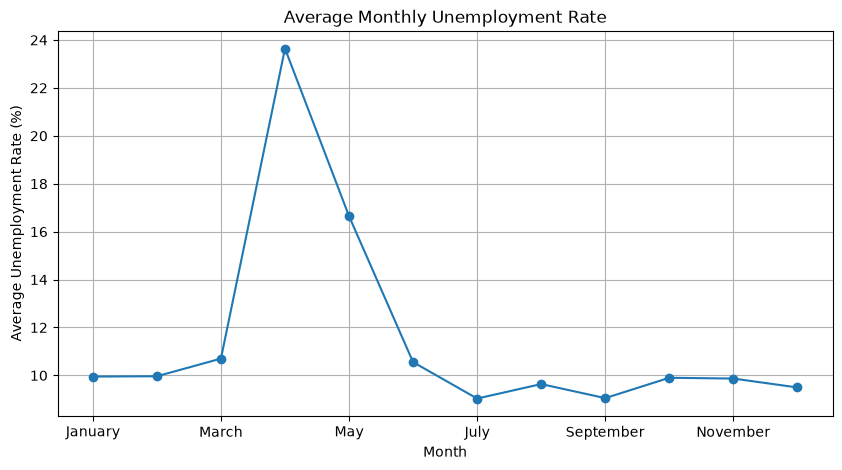

In [19]:
# Plot monthly unemployment trend

plt.figure(figsize=(10,5))

monthly_unemployment.plot(kind="line", marker="o")

plt.title("Average Monthly Unemployment Rate")
plt.xlabel("Month")
plt.ylabel("Average Unemployment Rate (%)")

plt.grid(True)

plt.show()

## Observation

The line chart shows how the average unemployment rate changes from month to month. Some months experienced higher unemployment rates than others, indicating seasonal or economic variations in employment across India.

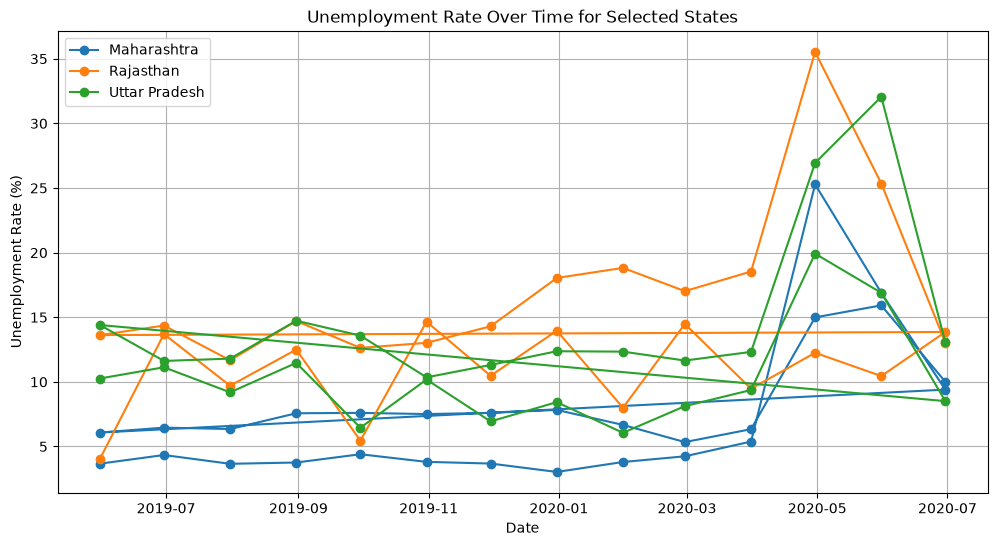

In [20]:
# Compare unemployment trends for selected states

states = ["Maharashtra", "Rajasthan", "Uttar Pradesh"]

plt.figure(figsize=(12,6))

for state in states:
    state_data = df[df["Region"] == state]

    plt.plot(
        state_data["Date"],
        state_data["Estimated Unemployment Rate (%)"],
        marker="o",
        label=state
    )

plt.title("Unemployment Rate Over Time for Selected States")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.legend()
plt.grid(True)

plt.show()

## Observation

The graph compares unemployment rates over time for Maharashtra, Rajasthan, and Uttar Pradesh. All three states experienced a significant increase in unemployment around April–May 2020, indicating the impact of the COVID-19 pandemic. Rajasthan and Uttar Pradesh showed sharper spikes than Maharashtra, highlighting differences in how regions were affected.

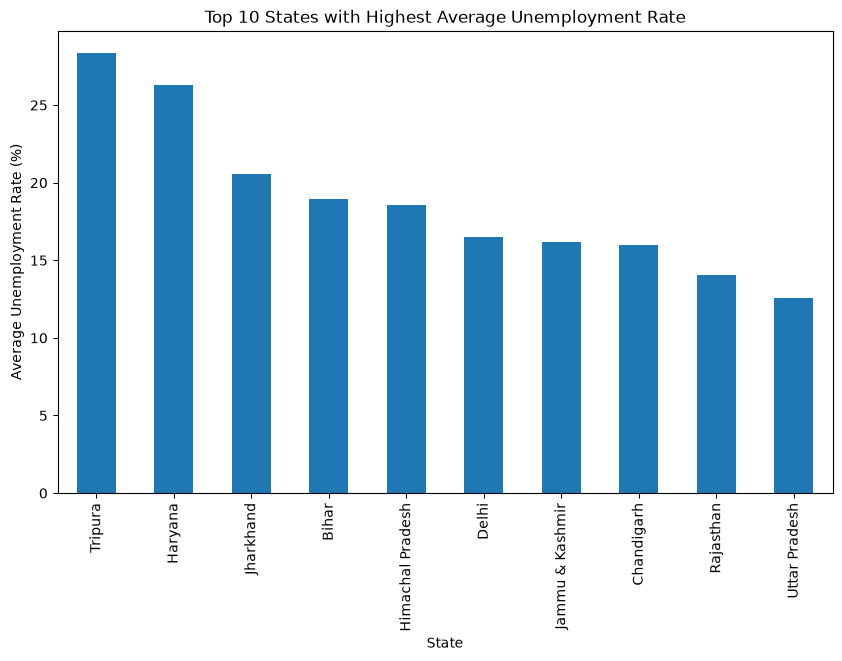

In [21]:
# Find the top 10 states with the highest average unemployment rate

top10 = df.groupby("Region")["Estimated Unemployment Rate (%)"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))

top10.plot(kind="bar")

plt.title("Top 10 States with Highest Average Unemployment Rate")
plt.xlabel("State")
plt.ylabel("Average Unemployment Rate (%)")



plt.show()

## Observation

The bar chart displays the top 10 states with the highest average unemployment rates. Tripura, Haryana, and Jharkhand are among the states with the highest unemployment, indicating greater employment challenges compared to other regions.

In [22]:
# Calculate correlation among unemployment-related features

correlation = df[
    [
        "Estimated Unemployment Rate (%)",
        "Estimated Employed",
        "Estimated Labour Participation Rate (%)"
    ]
].corr()

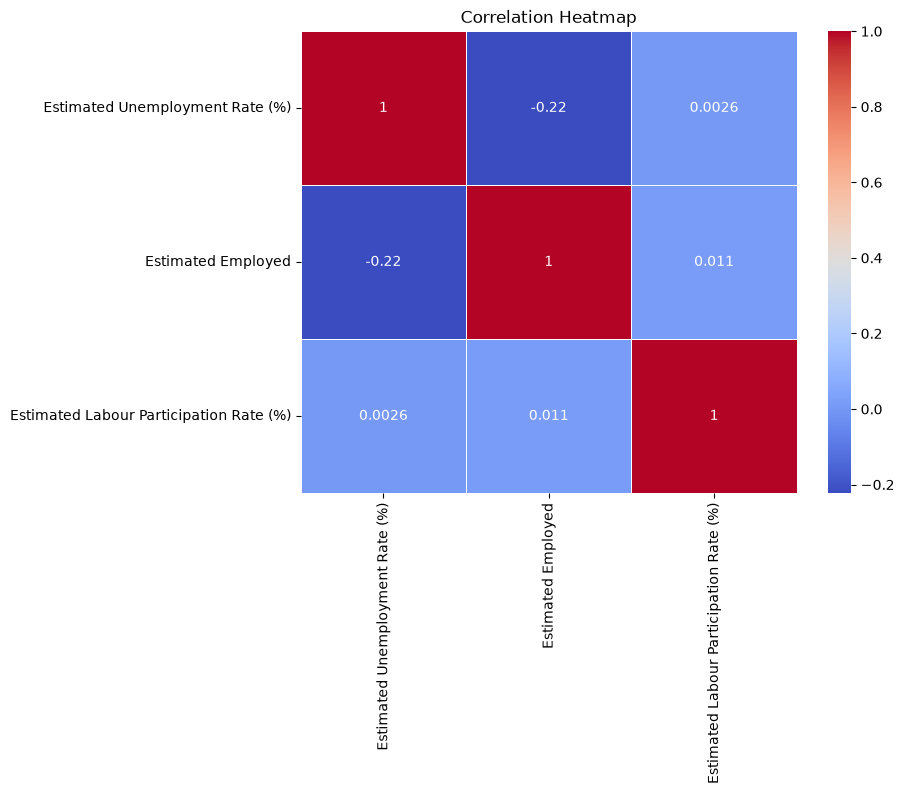

In [23]:
# Visualize the correlation matrix using a heatmap

plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

## Observation

The heatmap shows the relationship between unemployment rate, employment, and labour participation rate. Positive values indicate that two variables increase together, while negative values indicate that one variable tends to decrease as the other increases. This helps us understand how these employment-related factors are connected.

In [24]:
# Split the dataset into Pre-COVID and Post-COVID periods

pre_covid = df[df["Date"] < "2020-04-01"]
post_covid = df[df["Date"] >= "2020-04-01"]

In [25]:
# Calculate average unemployment rates before and after COVID-19

pre_avg = pre_covid["Estimated Unemployment Rate (%)"].mean()
post_avg = post_covid["Estimated Unemployment Rate (%)"].mean()

print("Pre-COVID Average:", pre_avg)
print("Post-COVID Average:", post_avg)

Pre-COVID Average: 9.61486394557823
Post-COVID Average: 20.194342105263157


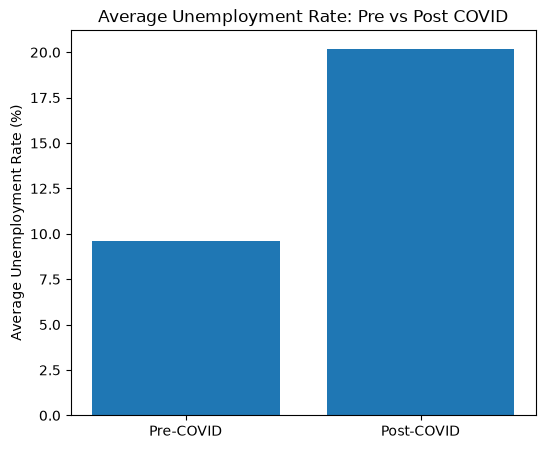

In [26]:
# Compare average unemployment rates before and after COVID-19

plt.figure(figsize=(6,5))

plt.bar(
    ["Pre-COVID", "Post-COVID"],
    [pre_avg, post_avg]
)

plt.title("Average Unemployment Rate: Pre vs Post COVID")
plt.ylabel("Average Unemployment Rate (%)")

plt.show()

## Observation

The comparison shows that the average unemployment rate increased after the COVID-19 outbreak. This rise reflects the economic impact of lockdowns and reduced employment opportunities during the pandemic.

# Conclusion

This analysis explored unemployment trends in India using Python. Data cleaning and exploratory data analysis were performed to understand regional and monthly unemployment patterns. Visualizations showed noticeable differences in unemployment across states and highlighted a significant increase in unemployment during the COVID-19 period. Correlation analysis provided insights into the relationship between unemployment, employment, and labour participation. Overall, the project demonstrates how data analysis can help identify employment trends and support informed decision-making.